In [89]:
# reading data and importing lib
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [90]:
data=pd.read_csv("student_dataset.csv")

In [91]:
# checking data
data.head()

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Result
0,1,Male,5.7,83.3,72.1,76.9,Pass
1,2,Male,4.2,80.6,77.1,66.0,Pass
2,3,Male,2.3,76.0,63.3,45.4,Pass
3,4,Female,2.2,72.3,95.1,60.5,Pass
4,5,Female,4.0,86.9,81.1,64.9,Pass


In [92]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      300 non-null    int64  
 1   Gender          290 non-null    str    
 2   Study_Hours     288 non-null    float64
 3   Attendance      290 non-null    float64
 4   Previous_Score  288 non-null    float64
 5   Final_Score     300 non-null    float64
 6   Result          300 non-null    str    
dtypes: float64(4), int64(1), str(2)
memory usage: 16.5 KB


In [93]:
#null values
data.isnull().sum()

Student_ID         0
Gender            10
Study_Hours       12
Attendance        10
Previous_Score    12
Final_Score        0
Result             0
dtype: int64

In [94]:
data.drop_duplicates()

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Result
0,1,Male,5.7,83.3,72.1,76.9,Pass
1,2,Male,4.2,80.6,77.1,66.0,Pass
2,3,Male,2.3,76.0,63.3,45.4,Pass
3,4,Female,2.2,72.3,95.1,60.5,Pass
4,5,Female,4.0,86.9,81.1,64.9,Pass
...,...,...,...,...,...,...,...
295,296,Female,5.3,91.4,45.2,62.5,Pass
296,297,Female,3.3,74.9,51.0,43.0,Pass
297,298,Male,6.4,88.5,50.4,72.2,Pass
298,299,Male,5.3,80.4,47.6,52.5,Pass


In [95]:
#outliers
# select num col
num=[]
cat=[]
for x in data.columns:
    if data[x].dtype=="str":
        cat.append(x)

    else:
        num.append(x)
print("cat",cat)
print("num",num)

cat ['Gender', 'Result']
num ['Student_ID', 'Study_Hours', 'Attendance', 'Previous_Score', 'Final_Score']


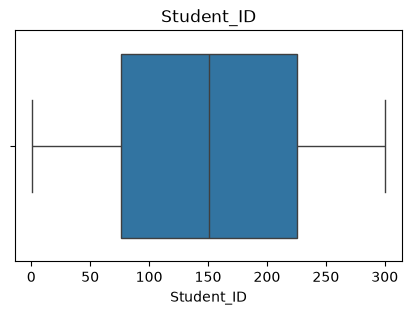

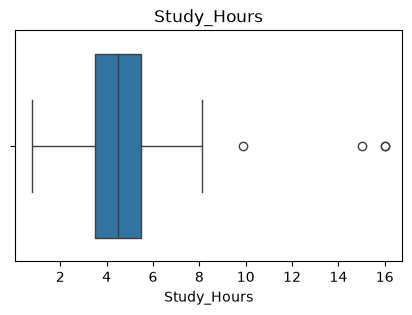

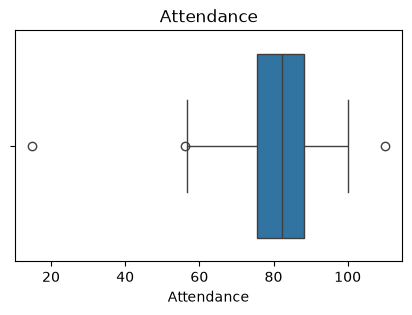

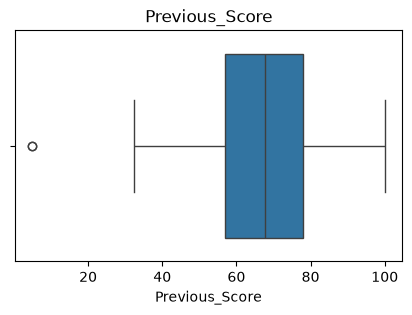

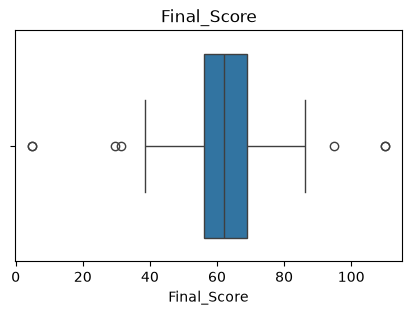

In [96]:
#box plot 
for col in num:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

In [97]:
for col in num:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower= Q1 - 1.5 * IQR
    upper= Q3 + 1.5 * IQR
    outlires= data[(data[col]<lower) | (data[col]>upper)]
    print(f"{col}: {len(outlires)}) outliners")

Student_ID: 0) outliners
Study_Hours: 4) outliners
Attendance: 3) outliners
Previous_Score: 2) outliners
Final_Score: 7) outliners


In [98]:
Q1 = data['Study_Hours'].quantile(0.25)
Q3 = data['Study_Hours'].quantile(0.75)
IQR = Q3 - Q1
    
lower= Q1 - 1.5 * IQR
upper= Q3 + 1.5 * IQR
data[(data['Study_Hours'] < lower) | (data['Study_Hours'] > upper)].index



Index([19, 40, 79, 149], dtype='int64')

In [99]:
data=data.drop([19,40,79,149])

In [100]:
data.sample()

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Result
197,198,Male,1.1,90.5,72.2,50.5,Pass


In [101]:
data.columns

Index(['Student_ID', 'Gender', 'Study_Hours', 'Attendance', 'Previous_Score',
       'Final_Score', 'Result'],
      dtype='str')

In [103]:
data.isnull().sum()

Student_ID         0
Gender            10
Study_Hours       12
Attendance        10
Previous_Score    12
Final_Score        0
Result             0
dtype: int64

In [109]:
data['Gender']=data['Gender'].fillna("Male")